# Введение в машинное обучение


## Теорема Байеса
Теорема Байеса — это фундаментальный результат теории вероятностей, который позволяет обновлять наши представления о вероятности события на основе новой информации. Она лежит в основе многих алгоритмов машинного обучения и является ключевым инструментом для принятия решений в условиях неопределенности.

<center>
<img src="../misc/images/bayes.png" alt="Описание изображения" />
</center>

### Задание 1. Условная вероятность
Прежде чем перейти к теореме Байеса, необходимо разобраться с понятием условной
вероятности. Условная вероятность P(A|B) показывает вероятность наступления события A при условии, что событие B уже произошло.

1. Напиши формулу условной вероятности в нотации LaTeX.
2. Реши следующую задачу: в коробке лежат 5 красных и 3 синих шара. Из коробки наугад вынимают два шара последовательно, без возврата. Какова вероятность того, что второй шар будет красным, если первый шар был синим? Вычисли ответ программно и выведи результат.
3. Реши следующую задачу: монету подбрасывают дважды. Событие A — первый бросок дал орла, событие B — второй бросок дал орла. Являются ли события A и B независимыми? Проверь это программно, вычислив P(A), P(B), P(A|B) и P(A и B). Сделай вывод о независимости событий.

P(A \mid B) = \frac{P(A \cap B)}{P(B)}

In [3]:
print(5/7)

0.7142857142857143


In [4]:
P_A = 1/2
P_B = 1/2
P_a_and_b = P_A * P_B
P_A_B = P_a_and_b / P_B 
print(bool(P_A_B == P_A))

True


### Задание 2. Тест на коронавирус

Теорема Байеса находит широкое применение в медицине, особенно при интерпретации результатов диагностических тестов.
<center>
<img src="../misc/images/error_type.png" alt="Типы ошибок" />
</center>

1. Напиши формулу теоремы Байеса в нотации LaTeX. Объясни, что означает каждый из компонентов формулы.
2. Дана задача: на планете живет 8 миллиардов человек. Известно, что заболел 1% населения. Тест на коронавирус имеет точность 95% (то есть 5% приходится на ошибки первого и второго рода: ложноположительные и ложноотрицательные результаты). Предположим, что вероятность ложноположительного результата (ошибка первого рода) составляет 5%, а вероятность ложноотрицательного результата (ошибка второго рода) составляет 5%. Ты сдал тест, и он оказался положительным. Какова вероятность того, что ты действительно болен? Реши задачу, используя теорему Байеса. Выведи результат с пояснениями.


P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}

In [5]:
P_A = 0.01
P_B_nA = 0.05
P_nB_A = 0.05
P_BA = 1 - P_nB_A
P_nA = 1 - P_A
P_B = P_A * P_BA + P_nA * P_B_nA

print((P_BA * P_A)/P_B)

0.16101694915254236


### Задание 3. Улучшаем тест

Результат предыдущей задачи показывает, что даже при высокой точности теста вероятность того, что человек действительно болен при положительном результате, может быть довольно низкой. Это связано с тем, что доля больных в популяции невелика (1%).

Врачи готовы улучшить тест, но могут исправить либо ошибку первого рода (ложноположительные результаты), либо ошибку второго рода (ложноотрицательные результаты). Необходимо выбрать, какую ошибку уменьшать.

<center>
<img src="../misc/images/dilemma.png" alt="Дилемма" />
</center>

1. Построй график зависимости вероятности P(болен|тест положительный) от изменения ошибки первого рода (ложноположительные результаты) при фиксированной ошибке второго рода (5%). Ошибка первого рода должна изменяться от 0% до 5% с шагом 0.5%.
2. Построй график зависимости вероятности P(болен|тест положительный) от изменения ошибки второго рода (ложноотрицательные результаты) при фиксированной ошибке первого рода (5%). Ошибка второго рода должна изменяться от 0% до 5% с шагом 0.5%.
3. Проанализируй оба графика и сделай вывод: какую ошибку следует уменьшать и почему? Объясни свой выбор, учитывая практические последствия ложноположительных и ложноотрицательных результатов в медицинской диагностике.

In [6]:
a = 0
P_AB_1 = (0.95*0.01)/0.0095+0.99*a

b = 0
P_AB_2 = ((1-b)*0.01)/0.0095+0.99*0.05

ТАБЛИЦА ЗНАЧЕНИЙ
a (α)    P_AB_1       b (β)    P_AB_2      
----------------------------------------------------------------------
0.0    % 100.00     % 0.0    % 16.81      %
0.5    % 65.74      % 0.5    % 16.74      %
1.0    % 48.97      % 1.0    % 16.67      %
1.5    % 39.01      % 1.5    % 16.60      %
2.0    % 32.42      % 2.0    % 16.53      %
2.5    % 27.74      % 2.5    % 16.46      %
3.0    % 24.23      % 3.0    % 16.39      %
3.5    % 21.52      % 3.5    % 16.31      %
4.0    % 19.35      % 4.0    % 16.24      %
4.5    % 17.58      % 4.5    % 16.17      %
5.0    % 16.10      % 5.0    % 16.10      %

ФОРМУЛЫ:
График 1: P_AB_1 = (0.95 × 0.01) / (0.0095 + 0.99 × a)
График 2: P_AB_2 = ((1 - b) × 0.01) / ((1 - b) × 0.01 + 0.05 × 0.99)


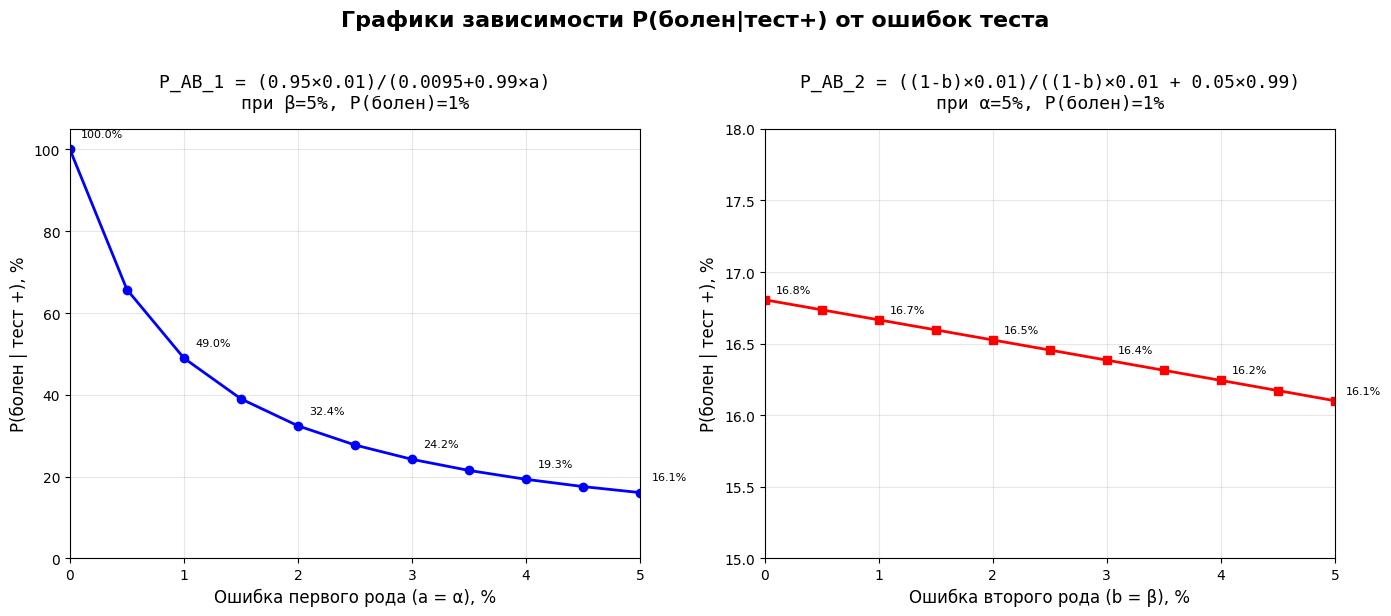

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Создаем массивы значений a и b от 0 до 0.05 с шагом 0.005
a_values = np.arange(0, 0.0501, 0.005)  # a = alpha (ошибка 1 рода)
b_values = np.arange(0, 0.0501, 0.005)  # b = beta (ошибка 2 рода)

# Расчет для первого графика: P_AB_1 = (0.95*0.01)/(0.0095+0.99*a)
ppv1_values = []
for a in a_values:
    numerator = 0.95 * 0.01  # 0.0095
    denominator = 0.0095 + 0.99 * a
    ppv1 = numerator / denominator if denominator != 0 else 1.0
    ppv1_values.append(ppv1)

# Расчет для второго графика: P_AB_2 = ((1-b)*0.01)/((1-b)*0.01 + 0.05*0.99)
ppv2_values = []
for b in b_values:
    numerator = (1 - b) * 0.01
    denominator = (1 - b) * 0.01 + 0.05 * 0.99
    ppv2 = numerator / denominator if denominator != 0 else 1.0
    ppv2_values.append(ppv2)

# Создаем графики
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Зависимость от a (alpha)
ax1 = axes[0]
ax1.plot(a_values * 100, np.array(ppv1_values) * 100, 'b-o', linewidth=2, markersize=6)
ax1.set_xlabel('Ошибка первого рода (a = α), %', fontsize=12)
ax1.set_ylabel('P(болен | тест +), %', fontsize=12)
ax1.set_title('P_AB_1 = (0.95×0.01)/(0.0095+0.99×a)\nпри β=5%, P(болен)=1%', 
              fontsize=13, pad=15, fontfamily='monospace')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)
ax1.set_xlim(0, 5)

# Добавляем значения на график 1
for i, (a, ppv) in enumerate(zip(a_values, ppv1_values)):
    if i % 2 == 0:  # показываем каждую вторую точку
        ax1.text(a*100 + 0.1, ppv*100 + 3, f'{ppv*100:.1f}%', 
                fontsize=8, ha='left')

# График 2: Зависимость от b (beta)
ax2 = axes[1]
ax2.plot(b_values * 100, np.array(ppv2_values) * 100, 'r-s', linewidth=2, markersize=6)
ax2.set_xlabel('Ошибка второго рода (b = β), %', fontsize=12)
ax2.set_ylabel('P(болен | тест +), %', fontsize=12)
ax2.set_title('P_AB_2 = ((1-b)×0.01)/((1-b)×0.01 + 0.05×0.99)\nпри α=5%, P(болен)=1%', 
              fontsize=13, pad=15, fontfamily='monospace')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(15, 18)
ax2.set_xlim(0, 5)

# Добавляем значения на график 2
for i, (b, ppv) in enumerate(zip(b_values, ppv2_values)):
    if i % 2 == 0:  # показываем каждую вторую точку
        ax2.text(b*100 + 0.1, ppv*100 + 0.05, f'{ppv*100:.1f}%', 
                fontsize=8, ha='left')

# Общий заголовок
fig.suptitle('Графики зависимости P(болен|тест+) от ошибок теста', 
             fontsize=16, y=1.02, fontweight='bold')

# Выводим таблицу значений
print("="*70)
print("ТАБЛИЦА ЗНАЧЕНИЙ")
print("="*70)
print(f"{'a (α)':<8} {'P_AB_1':<12} {'b (β)':<8} {'P_AB_2':<12}")
print("-"*70)

for i in range(len(a_values)):
    print(f"{a_values[i]*100:<7.1f}% {ppv1_values[i]*100:<11.2f}% "
          f"{b_values[i]*100:<7.1f}% {ppv2_values[i]*100:<11.2f}%")

print("\n" + "="*70)
print("ФОРМУЛЫ:")
print("="*70)
print("График 1: P_AB_1 = (0.95 × 0.01) / (0.0095 + 0.99 × a)")
print("График 2: P_AB_2 = ((1 - b) × 0.01) / ((1 - b) × 0.01 + 0.05 × 0.99)")

plt.tight_layout()
plt.show()

Вывод: нужно исправлять первую ошибку, так она сильнее влияет на результат

## Наивный байесовский классификатор

Наивный байесовский классификатор — это простой, но эффективный алгоритм классификации, основанный на
теореме Байеса. Его идея в том, чтобы сравнивать апостериорные вероятности классов \(P(y|x)\) и выбирать
класс с наибольшей вероятностью.

Алгоритм называют «наивным», потому что он делает упрощающее предположение об условной независимости
признаков при фиксированном классе. На практике это предположение часто нарушается, но модель все равно
работает хорошо: она быстро обучается, устойчива к высокоразмерным разреженным признакам и дает
интерпретируемые вероятности.

Исторически наивный Байес — один из первых алгоритмов, который широко применяли в реальных сервисах
машинного обучения, например, в антиспам‑фильтрах и задачах классификации текста.

В этом разделе ты обучишь наивный байесовский классификатор для определения спам‑сообщений в
электронной почте.

<center>
<img src="../misc/images/nbc.png" alt="NBC" />
</center>

### Задание 4. Загрузка данных

1. Загрузи данные из файла `datasets/emails.csv` с помощью библиотеки `pandas`. Файл содержит два столбца: `text` (текст письма) и `spam` (метка: 1 — спам, 0 — не спам).
2. Выведи размерность DataFrame (количество строк и столбцов).
3. Построй круговую диаграмму (pie chart) с помощью библиотеки `matplotlib`, отображающую распределение писем по классам (спам / не спам). Добавь легенду и информативный заголовок.

In [8]:
import pandas as pd

link = "C://Users/User/Desktop/ml1/AI_Machine_Learning.Project_1.ID_1577771-1/datasets/emails.csv"
emails = pd.read_csv(link)



In [9]:
emails.shape

(5728, 2)

In [10]:
emails.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [11]:
from collections import defaultdict

d = defaultdict(int)

for el in emails['spam']:
    d[el] += 1


Text(0.5, 1.0, 'Распределение категорий спама')

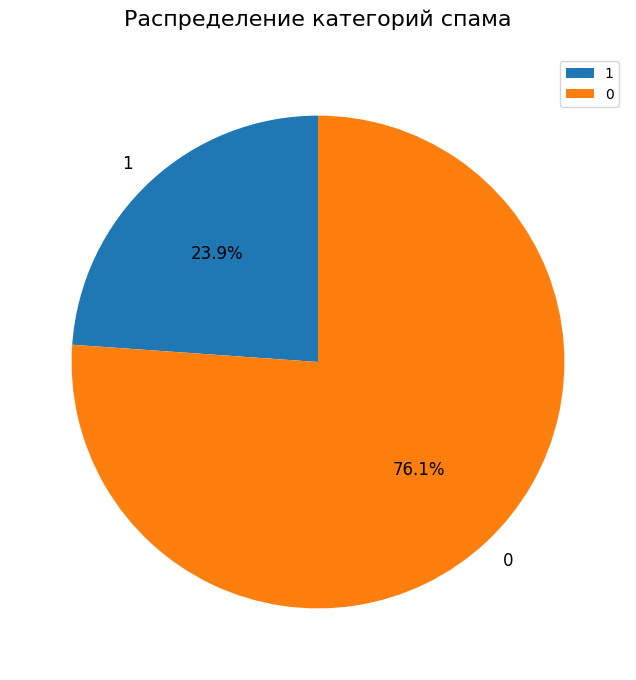

In [12]:
plt.figure(figsize=(8, 8))



plt.pie(
    [d[i] for i in d],  # данные (values)
    labels=[i for i in d],  # метки
    autopct='%1.1f%%',  # добавление процентов (рекомендуется)
    startangle=90,  # начинаем с 90 градусов
    textprops={'fontsize': 12}
)

plt.legend()
plt.title('Распределение категорий спама', fontsize=16, pad=20)

### Задание 5. Обработка текста

Перед обучением модели полезно «разобрать» тексты: убрать типовые артефакты вроде префикса `"Subject:"`,
посмотреть частотные слова в спаме и не спаме, а затем повторить анализ без стоп-слов. Это помогает увидеть,
какие слова действительно отличают классы, и понять, что именно будет влиять на решение классификатора.

1. Предобработай текстовое поле: удали префикс `Subject:` из начала каждого текста. Выведи несколько примеров текстов до и после обработки.

2. Удали из текстов слова короче 2 символов включительно.

3. Построй топ-50 самых частых слов для спам-сообщений и топ-50 самых частых слов для не спам-сообщений. Выведи результаты в виде двух списков или таблиц.

4. Загрузи список стоп-слов для английского языка из `sklearn.feature_extraction.text` (используй атрибут `stop_words` из `CountVectorizer`). Удали стоп-слова из текстов и снова построй топ-50 самых частых слов для спам-сообщений и топ-50 для не спам-сообщений.

In [13]:
emails['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

In [14]:
spam = defaultdict(int)
not_spam = defaultdict(int)

In [15]:
for idx in emails.index.to_list():
    emails.loc[idx, 'text'] = emails.loc[idx, 'text'].replace('Subject: ', '')
    for_work = [i for i in emails.loc[idx, 'text'].split(' ') if len(i) > 2]
    if emails.loc[idx, 'spam'] == 1:
        for i in for_work:
            spam[i] += 1
    else:
        for i in for_work:
            not_spam[i] += 1
            

In [16]:
sp = pd.DataFrame(
    list(spam.items()),
    columns=['word','count']    
)
sp.set_index('word',inplace=True)

In [17]:
not_sp = pd.DataFrame(
    list(not_spam.items()),
    columns=['word','count']    
)
not_sp.set_index('word',inplace=True)

In [18]:
sort_sp = sp.sort_values('count', ascending=False)
sort_not_sp = not_sp.sort_values('count', ascending=False)

In [19]:
sort_sp

,count
word,
the,8975
and,6517
you,4920
your,3730
for,3186
...,...
nominate,1
nationals,1
ubycvski,1


In [20]:
sort_not_sp

,count
word,
the,41135
and,20961
you,14234
for,13510
enron,13382
...,...
hrach,1
laird,1
jonalan,1


In [21]:
from sklearn.feature_extraction.text import CountVectorizer

stop_words = CountVectorizer(stop_words='english').get_stop_words()

In [22]:
spam = defaultdict(int)
not_spam = defaultdict(int)


In [23]:

for idx in emails.index.to_list():
    a = [i for i in emails.loc[idx, 'text'].split(' ')]
    for word in stop_words:
        a = [k for k in a if k != word]
    emails.loc[idx, 'text'] = ' '.join(a)
    for_work = [i for i in emails.loc[idx, 'text'].split(' ') if len(i) > 2]
    if emails.loc[idx, 'spam'] == 1:
        for i in for_work:
            spam[i] += 1
    else:
        for i in for_work:
            not_spam[i] += 1

sp = pd.DataFrame(
    list(spam.items()),
    columns=['word','count']    
)
sp.set_index('word',inplace=True)

not_sp = pd.DataFrame(
    list(not_spam.items()),
    columns=['word','count']    
)
not_sp.set_index('word',inplace=True)

sort_sp = sp.sort_values('count', ascending=False)
sort_not_sp = not_sp.sort_values('count', ascending=False)

In [24]:
sort_sp

,count
word,
com,998
business,844
company,805
email,804
information,740
...,...
farming,1
625,1
580,1


In [25]:
sort_not_sp

,count
word,
enron,13382
ect,11417
vince,8531
hou,5569
2000,4935
...,...
eriksson,1
fredrik,1
villeggiante,1


### Задание 6. Разделение на выборки

Перед обучением модели необходимо разделить данные на обучающую и тестовую выборки. Это позволяет оценить, насколько хорошо модель обобщается на новых данных, которые она не видела во время обучения.

<center>
<img src="../misc/images/split.png" alt="Split" />
</center>

1. Кратко объясни, зачем нужно разделять данные на обучающую и тестовую выборки. Что может произойти, если обучать и тестировать модель на одних и тех же данных?
2. Выдели признаки X (столбец `text`) и целевую переменную y (столбец `spam`).
3. Раздели данные на обучающую и тестовую выборки с помощью функции `train_test_split` из `sklearn.model_selection`. Используй параметры:
   - `test_size=0.2` (20% данных для теста);
   - `random_state=21` (для воспроизводимости результатов);
   - `stratify=y` (для сохранения пропорций классов в обеих выборках).
4. Выведи размерности `X_train`, `X_test`, `y_train`, `y_test`.

Зачем разделять данные?
Чтобы проверить, как модель работает на новых данных, которых она раньше не видела. Это имитирует реальную ситуацию.

Что будет без разделения?
Модель "сжульничает" — запомнит конкретные примеры вместо выявления общих закономерностей.

In [26]:
X = emails['text'].values
y = emails['spam'].values

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state=21,
    stratify=y
)

for i in [X_train, X_test, y_train, y_test]:
    print(i.shape)

(4582,)
(1146,)
(4582,)
(1146,)


### Задание 7. Преобразование данных

Текстовые данные нельзя напрямую подавать в алгоритмы машинного обучения, так как они работают с числовыми признаками. Необходимо преобразовать тексты в числовые векторы.

1. Кратко объясни, зачем нужно преобразовывать текстовые данные в числовые векторы. Какие методы для этого существуют?
2. Используй `CountVectorizer` из `sklearn.feature_extraction.text` для преобразования текстов в векторы частот слов (подход «Bag of Words»). При создании `CountVectorizer` укажи параметр `stop_words='english'` для автоматического удаления стоп-слов.
3. Обучи `CountVectorizer` на обучающей выборке (`fit`) и преобразуй обе выборки (`transform`). Выведи размерность полученных матриц признаков.

In [28]:
from sklearn.feature_extraction.text import CountVectorizer

vectories = CountVectorizer(stop_words='english')

X_train_vect = vectories.fit_transform(X_train)
X_test_vect = vectories.transform(X_test)


### Задание 8. Обучение модели

Теперь можно обучить наивный байесовский классификатор.

1. Импортируй `MultinomialNB` из `sklearn.naive_bayes` — это реализация наивного байесовского классификатора для дискретных признаков (частот слов).
2. Создай экземпляр классификатора и обучи его на обучающей выборке.
3. Сделай предсказания на тестовой выборке.
4. Вычисли метрику точности (accuracy) с помощью `accuracy_score` из `sklearn.metrics`. Выведи результат с пояснением.
5. Построй матрицу ошибок (confusion matrix) и выведи ее. Объясни, что показывает каждая ячейка матрицы.

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

model = MultinomialNB()

model.fit(X_train_vect, y_train)
predict = model.predict(X_test_vect)

accuracy = accuracy_score(y_test, predict)
cm = confusion_matrix(y_test, predict)

print(f"\nМатрица ошибок:")
print(f"               Предсказано 0   Предсказано 1")
print(f"Фактически 0:      {cm[0,0]:5}           {cm[0,1]:5}")
print(f"Фактически 1:      {cm[1,0]:5}           {cm[1,1]:5}")


Матрица ошибок:
               Предсказано 0   Предсказано 1
Фактически 0:        867               5
Фактически 1:          4             270


### Задание 9. Отравление модели

Наивный байесовский классификатор уязвим к атакам типа «отравление модели» (model poisoning). Это происходит, когда злоумышленник добавляет в спам-сообщения слова, которые обычно встречаются в **не** спам-сообщениях, чтобы обмануть классификатор.

<center>
<img src="../misc/images/poison.png" alt="Poison" />
</center>

1. Выбери несколько спам-сообщений из тестовой выборки (например, 3–5 сообщений).
2. Добавь в каждое из них слова, которые имеют высокую вероятность встречаться в не спам-сообщениях (например, слова из топ-50 не спам-сообщений, которые редко встречаются в спаме). Добавь достаточно много таких слов (например, повтори каждое слово 5–10 раз).
3. Преобразуй модифицированные тексты с помощью обученного `CountVectorizer`.
4. Используй обученную модель для предсказания вероятности того, что модифицированные сообщения являются спамом. Используй метод `predict_proba` для получения вероятностей.
5. Проанализируй результаты: изменилась ли вероятность того, что сообщения классифицируются как спам? Сделай вывод об уязвимости модели. В выводе ответь на следующие вопросы:
   - Насколько сильно изменилась вероятность классификации как спам после добавления слов из не спам-сообщений?
   - Почему наивный байесовский классификатор уязвим к таким атакам? Свяжи это с тем, как модель вычисляет вероятности классов.
   - Какие практические последствия имеет эта уязвимость для реальных систем фильтрации спама?
   - Какие меры можно предпринять для защиты от подобных атак?

In [30]:
sort_not_sp

,count
word,
enron,13382
ect,11417
vince,8531
hou,5569
2000,4935
...,...
eriksson,1
fredrik,1
villeggiante,1


In [31]:
array = []
for idx in range(len(X_test)-1):
    if len(array) < 5:
        if y_test[idx] == 1:
            array.append(X_test[idx])
    else:
        break

In [32]:
words_for_add = sort_not_sp.index[:5]

for word in words_for_add:
    for i in range(len(array)):
        array[i] = array[i] + ' ' + (word + ' ') * 9 + word


In [33]:
array_vect = vectories.transform(array)

In [34]:
predict = model.predict_proba(array_vect)

In [35]:
predict

array([[1.00000000e+000, 6.06839041e-104],
       [1.00000000e+000, 3.11620242e-125],
       [1.00000000e+000, 1.68742722e-127],
       [1.00000000e+000, 3.44220512e-082],
       [1.00000000e+000, 9.81379841e-104]])

Анализ:
Спам, в который добавили слова из легитимных писем, резко теряет свою оценку: вероятность спама падае.  
Это происходит из-за мультипликативного сочетания независимых признаков в наивном Байесе — каждое «хорошее» слово экспоненциально снижает итоговую вероятность спам-класса, легко перевешивая типично спамовые термины.  
На практике спамеры могут обходить фильтр, вставляя безобидные фразы; эффективность системы падает, требуется постоянное дообучение.  
Защита: переход на устойчивые модели (логистическая регрессия, SVM, boosting), использование N‑грамм, состязательное обучение и ансамблирование с другими правилами.

### Задание 10. TF-IDF вместо CountVectorizer

Используй TF-IDF преобразование, которое ты уже реализовывал в предыдущих проектах — оно позволяет учитывать не только частоту, но и редкость слова в коллекции.

1. Замени `CountVectorizer` на `TfidfVectorizer` из `sklearn.feature_extraction.text`. Используй те же параметры (`stop_words='english'`).
2. Обучи `TfidfVectorizer` на обучающей выборке и преобразуй обе выборки.
3. Обучи новый наивный байесовский классификатор на преобразованных данных.
4. Вычисли точность на тестовой выборке и сравни с результатом из Задания 8. Сделай вывод: какой метод показал лучший результат?

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectories_2 = TfidfVectorizer(stop_words='english')
X_train_tfidf = vectories_2.fit_transform(X_train)
X_test_tfidf = vectories_2.transform(X_test)

In [37]:
model2 = MultinomialNB()

In [38]:
model2.fit(X_train_tfidf,y_train)
predict = model.predict(X_test_tfidf)
predict

array([0, 0, 0, ..., 0, 0, 0], shape=(1146,))

In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predict)

print(f"\nМатрица ошибок:")
print(f"               Предсказано 0   Предсказано 1")
print(f"Фактически 0:      {cm[0,0]:5}           {cm[0,1]:5}")
print(f"Фактически 1:      {cm[1,0]:5}           {cm[1,1]:5}")


Матрица ошибок:
               Предсказано 0   Предсказано 1
Фактически 0:        870               2
Фактически 1:          5             269


## Бонусное задание. Байесовский вывод


Бонусные задания помогут тебе глубже понять теоретические основы байесовского подхода и почувствовать
разницу между «оценить параметр» и «оценить неопределенность».

Представь, что у тебя есть монетка с неизвестной вероятностью выпадения орла. Возможно,
она нечестная и вероятность не 50/50. Тебе хочется оценить **параметр p** по данным.

Единственное, что ты можешь сделать с этой монеткой, — это подбрасывать ее и наблюдать результаты
(орел/решка). Эти наблюдения и станут данными D, а байесовский вывод поможет обновить твои
представления о p: от априорного предположения к апостериорному распределению P(p|D).

В отличие от MLE (Maximum Likelihood Estimation, оценка максимального правдоподобия), байесовский подход дает не одну точку p̂, а целое распределение: оно показывает,
насколько ты уверен в оценке при малом числе бросков и как уверенность растет по мере накопления данных.


<center>
<img src="../misc/images/coin.png" alt="Coin" />
</center>

### Задание 11. Правдоподобие и оценка MLE для монетки

Представим, что мы подбросили монетку 10 раз и получили 7 орлов и 3 решки.

Мы хотим оценить параметр p по данным. Для этого удобно рассмотреть
функцию правдоподобия L(p): она показывает, насколько вероятно получить **именно такую выборку**
(7 орлов и 3 решки), если «истинная» вероятность орла равна p.

По сути, правдоподобие L(p) = P(D|p) — это вероятность наблюдать такие данные \(D\) при условии,
что параметр модели равен \(p\). Это та самая условная вероятность, которая встречается в теореме Байеса.

1. Запиши функцию правдоподобия L(p) и лог‑правдоподобия log(L(p)) для этой
   задачи.
2. Найди оценку максимального правдоподобия p̂.
3. Построй график L(p) или log(L(p))  на диапазоне [0,1] и отметь на нем точку p̂.


i=1
∏
n
​
 f(x 
i
​
 ∣θ)
 

ℓ(θ∣X)=logL(θ∣X)= 
i=1
∑
n
​
 logf(X 
i
​
 ∣θ)

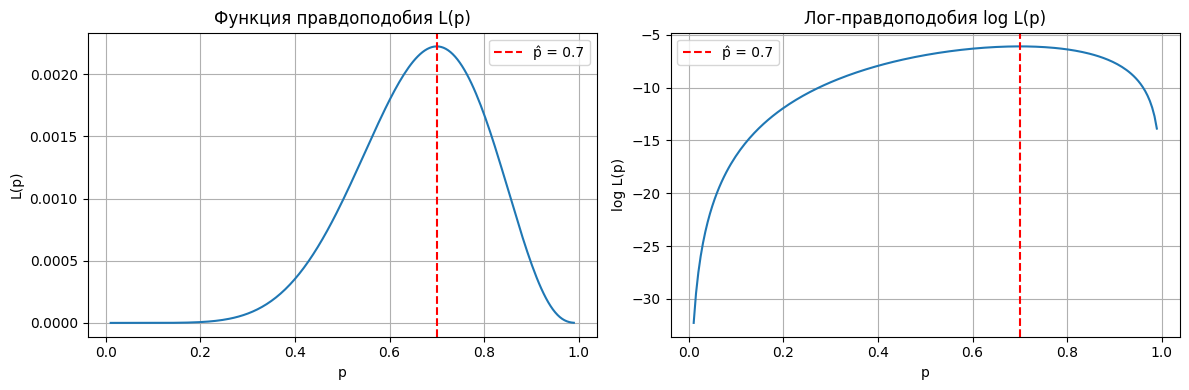

In [40]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(0.01, 0.99, 200)
L = p**7 * (1-p)**3
logL = 7*np.log(p) + 3*np.log(1-p)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(p, L)
plt.xlabel('p')
plt.ylabel('L(p)')
plt.axvline(0.7, color='red', linestyle='--', label=f'p̂ = 0.7')
plt.title('Функция правдоподобия L(p)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(p, logL)
plt.xlabel('p')
plt.ylabel('log L(p)')
plt.axvline(0.7, color='red', linestyle='--', label=f'p̂ = 0.7')
plt.title('Лог-правдоподобия log L(p)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Задание 12. Байесовский вывод: априорное и апостериорное распределения


Мы дали оценку с правдоподобием и лог‑правдоподобием. Важно помнить: log(L(p)) — это просто
«оценка того, насколько данные согласуются с параметром p». Это **не** распределение вероятностей по p:
оно не нормируется до 1 и вообще ничем не ограничено — лог‑правдоподобие может уходить на бесконечность.

При этом по графику log(L(p)) ты уже примерно видишь, какие значения p выглядят правдоподобными, а какие
— нет. Байесовский подход делает следующий шаг: мы явно описываем наши ожидания о p **до** наблюдения данных
в виде априорного распределения P(p), а затем «обновляем» его данными и получаем апостериор P(p|D).

Зачем нужно априорное распределение P(D):

1. Оно фиксирует то, что ты знаешь (или предполагаешь) о параметре до данных. Например, что монетка «скорее
   честная» или, наоборот, возможен сильный перекос.
2. Оно делает вывод устойчивее при малом числе наблюдений: когда данных мало, MLE может быть шумной, а приор
   «стягивает» оценки к разумным значениям.
3. Оно позволяет работать с неопределенностью: вместо одной точки для p ты получаешь распределение,
   показывающее уверенность в разных значениях параметра.

1. Выбери априорное распределение для p в виде распределения Beta(alpha,beta).
   Для вычислений/семплирования ты можешь использовать SciPy:
   [scipy.stats.beta](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.beta.html).
   Объясни, как alpha, beta интерпретируются как «псевдонаблюдения».
2. Запиши параметры апостериорного распределения после 7 орлов и 3 решек. Проверь это программно.
3. Посчитай и выведи: апостериорное среднее E[p|D] и MAP‑оценку (Maximum A Posteriori, оценка максимума апостериорной вероятности). Коротко сравни их с
   p̂ из MLE.

### Задание 13. Байесовские предсказания и неопределенность

Байесовский вывод полезен тем, что позволяет не только оценить p, но и измерить неопределенность.


1. Найди апостериорное предсказание для следующего броска: P(орел|D).
2. Оцени 95% доверительный интервал для p (например, по квантилям апостериорного распределения).
3. Покажи, как меняется ширина интервала при увеличении числа бросков (например, сравни 10 и 100 бросков при
   той же доле орлов). Сделай вывод. В выводе ответь на следующие вопросы:
   - Как изменилась ширина 95% доверительного интервала при увеличении числа наблюдений?
   - Почему это происходит? Свяжи это с тем, как апостериорное распределение обновляется при получении новых данных.
   - Что это означает для практики: когда мы можем быть более уверены в оценке параметра p?